# **<font color="#0000ff">REGULARIZACIÓN</font>**

**Dataset:** Impacto de las Redes Sociales en la Salud Mental de los Adolescentes

**Variable objetivo:** `stress_level` (Nivel de estrés 1–10)

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

# Configuración matplotlib
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importar data
datos = pd.read_excel('datosestresyansiedad.xlsx')

# Convertir variables categóricas a dummies (drop_first evita multicolinealidad)
# Las variables cualitativas aquí entran como cuantitativas (dummies)
datos = pd.get_dummies(
    datos,
    columns=['gender', 'platform_usage', 'social_interaction_level'],
    drop_first=True,
    dtype=int
)
datos

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,stress_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,1,0,2,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,1,10,0,8,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,4,2,0,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,7,9,0,1,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,5,2,0,3,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,4,4,0,3,0,1,0,1,0
1196,16,2.3,8.0,1.9,2.12,0.4,4,4,0,7,1,0,0,0,0
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,0,1,0,0,0,0,0
1198,15,3.9,8.5,2.1,3.19,0.6,9,9,0,7,1,0,0,0,0


In [3]:
# Observando la estructura de la data
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1200 non-null   int64  
 1   daily_social_media_hours         1200 non-null   float64
 2   sleep_hours                      1200 non-null   float64
 3   screen_time_before_sleep         1200 non-null   float64
 4   academic_performance             1200 non-null   float64
 5   physical_activity                1200 non-null   float64
 6   anxiety_level                    1200 non-null   int64  
 7   addiction_level                  1200 non-null   int64  
 8   depression_label                 1200 non-null   int64  
 9   stress_level                     1200 non-null   int64  
 10  gender_male                      1200 non-null   int64  
 11  platform_usage_Instagram         1200 non-null   int64  
 12  platform_usage_TikTo

In [4]:
# Correlación entre columnas numéricas
# Función para convertir una matriz de correlación de pandas en formato tidy
def tidy_corr_matrix(corr_mat):
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1', 'variable_2', 'r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)
    return corr_mat

corr_matrix = datos.select_dtypes(include=['float64', 'int64', 'int32', 'uint8']) \
              .corr(method='pearson')
display(tidy_corr_matrix(corr_matrix).head(10))

,variable_1,variable_2,r,abs_r
209,social_interaction_level_low,social_interaction_level_medium,-0.529636,0.529636
223,social_interaction_level_medium,social_interaction_level_low,-0.529636,0.529636
177,platform_usage_Instagram,platform_usage_TikTok,-0.508437,0.508437
191,platform_usage_TikTok,platform_usage_Instagram,-0.508437,0.508437
38,sleep_hours,depression_label,-0.190630,0.190630
122,depression_label,sleep_hours,-0.190630,0.190630
121,depression_label,daily_social_media_hours,0.175201,0.175201
23,daily_social_media_hours,depression_label,0.175201,0.175201
143,stress_level,depression_label,0.170474,0.170474
129,depression_label,stress_level,0.170474,0.170474


In [5]:
# Seleccionando variables independientes y dependiente
y = datos['stress_level']
X = datos.drop(columns=['stress_level'])

feature_names = X.columns.tolist()
print("Variables predictoras:")
print(feature_names)

Variables predictoras:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [6]:
# División de los datos en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size   = 0.8,
    random_state = 1234,
    shuffle      = True
)

In [7]:
# Observando la data X_train, data de entrenamiento
X_train

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
230,17,2.4,8.5,2.4,2.79,1.1,6,7,0,1,0,1,1,0
1171,14,5.7,6.4,1.9,3.30,1.3,8,5,0,0,0,1,0,0
1099,15,7.8,4.6,3.0,2.44,1.4,10,6,1,0,1,0,0,1
208,15,2.2,5.2,1.4,2.62,1.5,7,5,0,1,1,0,0,1
1070,15,7.3,5.7,2.9,3.48,1.8,7,8,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,16,1.7,4.3,1.4,3.27,1.2,4,10,0,1,0,0,0,1
664,18,2.2,4.5,2.0,2.49,0.8,7,6,0,1,0,0,0,0
1077,14,5.1,5.3,2.3,2.31,0.2,3,6,0,0,1,0,0,0
723,13,2.3,6.6,1.4,3.74,1.5,10,1,0,0,0,1,0,1


In [8]:
# Escalando las variables independientes
# Solo se escalan las variables numéricas continuas; las dummies NO se escalan
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label']

scaler = StandardScaler()

X_train_std = X_train.copy().reset_index(drop=True)
X_test_std  = X_test.copy().reset_index(drop=True)

X_train_std[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_std[num_cols]  = scaler.transform(X_test[num_cols])

df_train = pd.DataFrame(X_train_std, columns=feature_names)
df_test  = pd.DataFrame(X_test_std,  columns=feature_names)

print(df_train)
print(df_test)

          age  daily_social_media_hours  sleep_hours  \
0    0.515268                 -1.030839     1.393522   
1   -0.949659                  0.599809    -0.049163   
2   -0.461350                  1.637494    -1.285750   
3   -0.461350                 -1.129666    -0.873554   
4   -0.461350                  1.390426    -0.530058   
..        ...                       ...          ...   
955  0.026959                 -1.376734    -1.491848   
956  1.003577                 -1.129666    -1.354450   
957 -0.949659                  0.303327    -0.804855   
958 -1.437968                 -1.080253     0.088236   
959  0.515268                 -0.586117    -0.873554   

     screen_time_before_sleep  academic_performance  physical_activity  \
0                    0.940463             -0.361200           0.165055   
1                    0.239061              0.521121           0.510269   
2                    1.782146             -0.966715           0.682876   
3                   -0.462341  

# **<font color="#0000ff">MODELOS</font>**
Se ajustan varios modelos lineales con y sin regularización, con el objetivo de identificar cuál de ellos es capaz de predecir mejor

# <font color="#0000ff">Mínimos cuadrados (OLS)</font>

In [9]:
# Creación y entrenamiento del modelo
# ===================================
modelo = LinearRegression()
modelo.fit(X=df_train, y=y_train)

LinearRegression()

In [10]:
# Coeficientes del modelo
# =======================
df_coeficientes = pd.DataFrame({
    'predictor': feature_names,
    'coef'     : modelo.coef_.flatten()
})
df_coeficientes

,predictor,coef
0,age,-0.061501
1,daily_social_media_hours,0.016854
2,sleep_hours,0.020385
3,screen_time_before_sleep,0.012946
4,academic_performance,0.036282
5,physical_activity,0.028081
6,anxiety_level,-0.000976
7,addiction_level,-0.016588
8,depression_label,0.504867
9,gender_male,0.134795


Evaluamos el modelo

In [11]:
# Predicciones test
# ================
predicciones = modelo.predict(X=df_test)
predicciones = predicciones.flatten()
predicciones[:7]

array([5.70085809, 5.41719448, 5.09775553, 5.52159491, 5.36009927,
       5.26985685, 5.43380262])

In [12]:
# Error de test del modelo
# =========================
rmse_ols = np.sqrt(mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
))
print("")
print(f"El error (rmse) es: {rmse_ols}")


El error (rmse) es: 2.844053111958142


# <font color="#0000ff">Ridge</font>

In [13]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ===========================
# Por defecto RidgeCV utiliza el mean squared error
modelo = RidgeCV(
    alphas          = np.logspace(-10, 2, 200),
    fit_intercept   = True,
    store_cv_values = True
)

_ = modelo.fit(X=df_train, y=y_train)

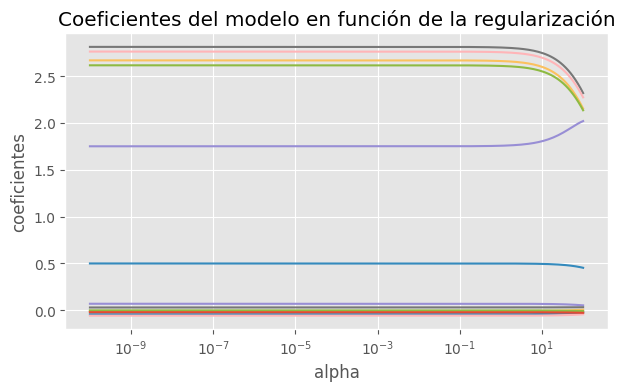

In [14]:
# Evolución de los coeficientes en función de alpha
# ===============================
alphas = modelo.alphas
coefs  = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(df_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.axis('tight')
plt.show()

A medida que aumenta el valor de alpha, la regularización es mayor y el valor de los coeficientes se reduce.

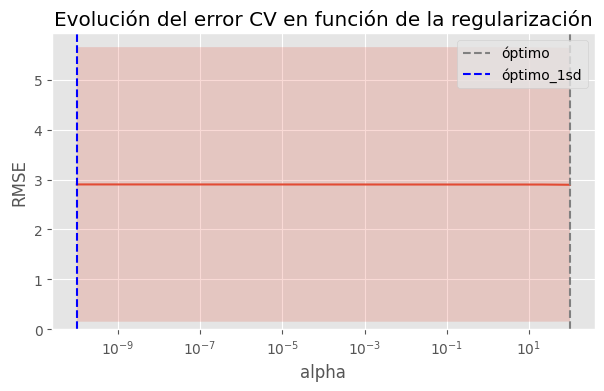

In [15]:
# Evolución del error en función de alpha
# ========================================
# modelo.cv_values_ almacena el mse de cv para cada valor de alpha.
# Tiene dimensiones (n_samples, n_targets, n_alphas)
mse_cv = modelo.cv_values_.reshape((-1, 200)).mean(axis=0)
mse_sd = modelo.cv_values_.reshape((-1, 200)).std(axis=0)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rsme_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas[rmse_cv == min_rsme_1sd]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas, rmse_cv)
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

El óptimo está entre 10⁻¹ y 10⁺¹

In [16]:
# Mejor valor alpha encontrado
# =============================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 100.0


In [17]:
# Coeficientes del modelo
# =======================
df_coeficientes = pd.DataFrame({
    'predictor': feature_names,
    'coef'     : modelo.coef_.flatten()
})
df_coeficientes

,predictor,coef
0,age,-0.054654
1,daily_social_media_hours,0.022206
2,sleep_hours,0.008654
3,screen_time_before_sleep,0.009253
4,academic_performance,0.031994
5,physical_activity,0.026331
6,anxiety_level,0.006969
7,addiction_level,-0.015096
8,depression_label,0.451332
9,gender_male,0.091291


Text(0.5, 1.0, 'Coeficientes del modelo Ridge')

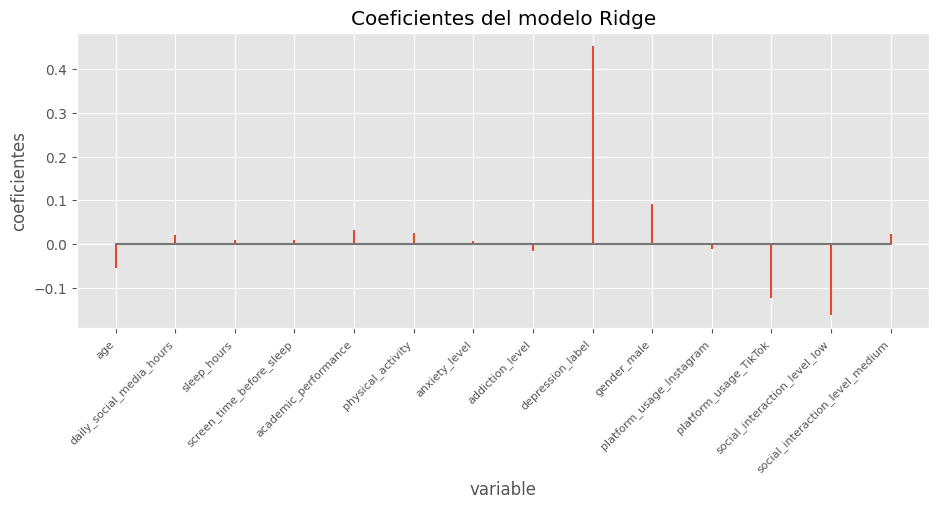

In [18]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=8)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo Ridge')

In [19]:
# Predicciones test
# ================
predicciones = modelo.predict(X=df_test)
predicciones = predicciones.flatten()
predicciones[:7]

array([5.62852171, 5.39300251, 5.16484936, 5.54723125, 5.41430715,
       5.30651107, 5.43435367])

In [20]:
# Error de test del modelo
# ==========================================
rmse_ridge = np.sqrt(mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
))
print("")
print(f"El error (rmse) de test es: {rmse_ridge}")


El error (rmse) de test es: 2.8454130970986857


# <font color="#0000ff">Lasso</font>

In [21]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# =====================================
# Por defecto LassoCV utiliza el mean squared error
modelo = LassoCV(
    alphas = np.logspace(-10, 3, 200),
    cv     = 10
)
_ = modelo.fit(X=df_train, y=y_train)

Text(0.5, 1.0, 'Coeficientes del modelo Lasso en función de la regularización')

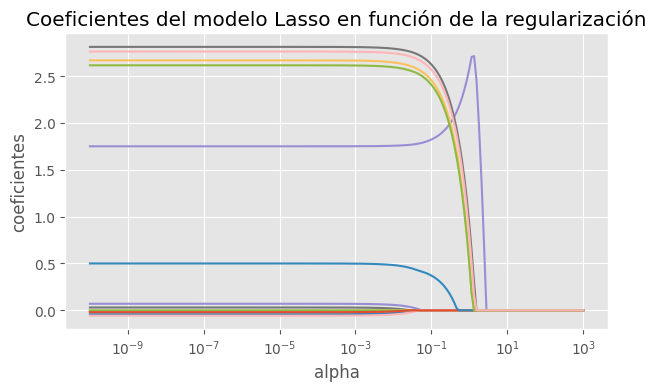

In [22]:
# Evolución de los coeficientes en función de alpha
# ==============================================================================
alphas = modelo.alphas_
coefs  = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(df_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo Lasso en función de la regularización')

Text(0.5, 1.0, 'Predictores incluidos en función de la regularización')

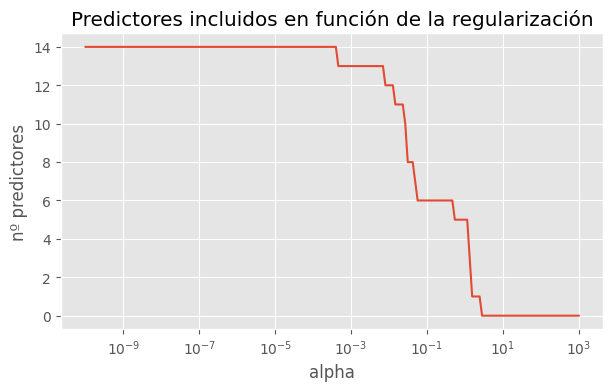

In [23]:
# Número de predictores incluidos (coeficiente != 0) en función de alpha
# ====================================
alphas        = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(df_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Predictores incluidos en función de la regularización')

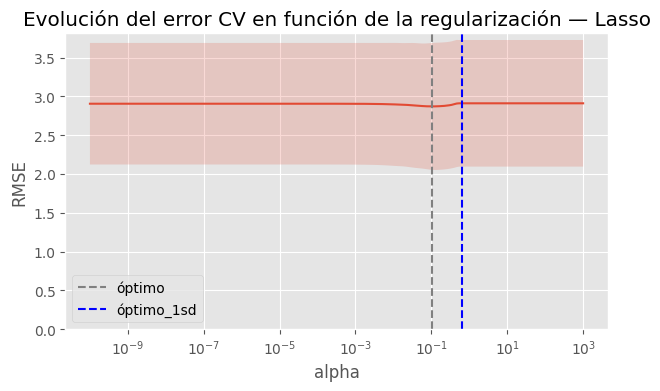

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

# Assuming 'modelo' is an instance of LassoCV and has been fitted
# For demonstration, let's create dummy data for modelo.alphas_ and modelo.mse_path_
# In a real scenario, these would come from your pre-run cells
if 'modelo' not in locals():
    # This part is just for the snippet to be runnable independently if needed
    # In the notebook context, 'modelo' should already exist from previous cells
    modelo = LassoCV(alphas=np.logspace(-10, 3, 200))
    # Dummy data, replace with actual modelo.mse_path_ shape (n_alphas, n_folds)
    num_alphas = len(modelo.alphas_)
    num_folds = 10
    modelo.mse_path_ = np.random.rand(num_alphas, num_folds) * 2 + 1 # Simulate some MSE values

# Evolución del error en función de alpha
# ==============================================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha.
# Tiene dimensiones (n_alphas, n_folds)
mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rsme_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rsme_1sd][-1] # Fixed: Select the last (largest) alpha if multiple exist

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización — Lasso')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()

In [25]:
# Mejor valor alpha encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 0.10353218432956658


In [26]:
# Mejor valor alpha encontrado + 1sd
# ==============================================================================
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rsme_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rsme_1sd]

print(f"Mejor valor de alpha encontrado + 1 desviación estándar: {optimo_1sd}")

Mejor valor de alpha encontrado + 1 desviación estándar: [1.00000000e+03 8.60346442e+02 7.40196000e+02 6.36824994e+02
 5.47890118e+02 4.71375313e+02 4.05546074e+02 3.48910121e+02
 3.00183581e+02 2.58261876e+02 2.22194686e+02 1.91164408e+02
 1.64467618e+02 1.41499130e+02 1.21738273e+02 1.04737090e+02
 9.01101825e+01 7.75259749e+01 6.66991966e+01 5.73844165e+01
 4.93704785e+01 4.24757155e+01 3.65438307e+01 3.14403547e+01
 2.70495973e+01 2.32720248e+01 2.00220037e+01 1.72258597e+01
 1.48202071e+01 1.27505124e+01 1.09698580e+01 9.43787828e+00
 8.11984499e+00 6.98587975e+00 6.01027678e+00 5.17092024e+00
 4.44878283e+00 3.82749448e+00 3.29297126e+00 2.83309610e+00
 2.43744415e+00 2.09704640e+00 1.80418641e+00 1.55222536e+00
 1.33545156e+00 1.14895100e+00 9.88495905e-01 8.50448934e-01
 7.31680714e-01 6.29498899e-01]


Se entrena de nuevo el modelo, esta vez empleando el mayor valor de alpha cuyo error está a menos de una desviación típica del mínimo encontrado en la validación cruzada

In [27]:
# Mejor modelo alpha óptimo + 1sd
# ===============================
modelo_lasso_1sd = Lasso(alpha=optimo_1sd[0])
modelo_lasso_1sd.fit(df_train, y_train)

Lasso(alpha=np.float64(1000.0))

In [28]:
# Coeficientes del modelo Lasso (alpha óptimo + 1sd)
# ===================================================
df_coeficientes_lasso = pd.DataFrame({
    'predictor': feature_names,
    'coef'     : modelo_lasso_1sd.coef_.flatten()
})

# Predictores incluidos en el modelo (coeficiente != 0)
print("Predictores seleccionados por Lasso (coef ≠ 0):")
print(df_coeficientes_lasso[df_coeficientes_lasso.coef != 0])

Predictores seleccionados por Lasso (coef ≠ 0):
Empty DataFrame
Columns: [predictor, coef]
Index: []


Text(0.5, 1.0, 'Coeficientes del modelo Lasso (alpha óptimo + 1sd)')

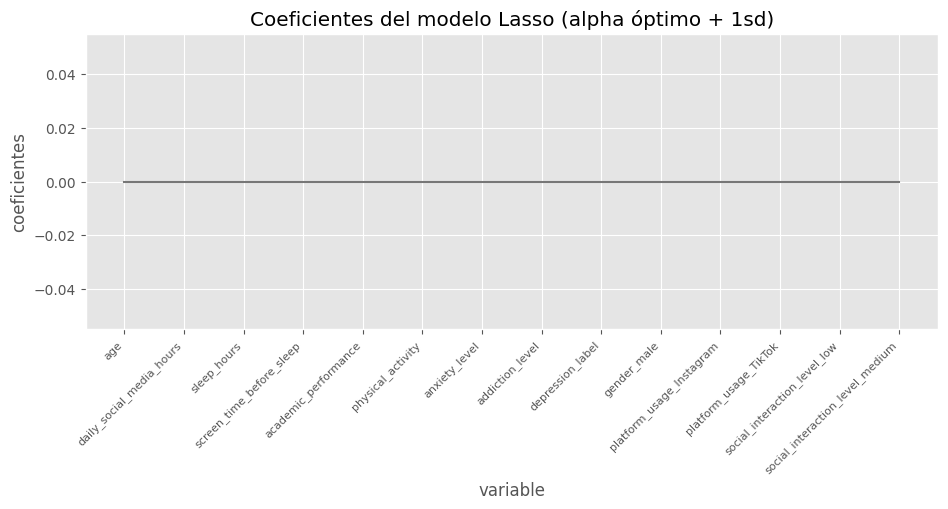

In [29]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes_lasso.predictor, df_coeficientes_lasso.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=8)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo Lasso (alpha óptimo + 1sd)')

In [30]:
# Predicciones test
# ================================================
predicciones = modelo_lasso_1sd.predict(X=df_test)
predicciones = predicciones.flatten()
predicciones[:7]

array([5.43854167, 5.43854167, 5.43854167, 5.43854167, 5.43854167,
       5.43854167, 5.43854167])

In [31]:
# Error de test del modelo
# ================================================
rmse_lasso = np.sqrt(mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
))
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")


El error (rmse) de test es: 2.8796477001077947


# <font color="#0000ff">Elastic Net</font>

In [32]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# =========================================================
# Por defecto ElasticNetCV utiliza el mean squared error
modelo = ElasticNetCV(
    l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas   = np.logspace(-10, 3, 200),
    cv       = 10
)
_ = modelo.fit(X=df_train, y=y_train)

In [33]:
# Evolución del error en función de alpha y l1_ratio
# =========================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha y l1_ratio.
# Tiene dimensiones (n_l1_ratio, n_alpha, n_folds)

# Error medio de las 10 particiones por cada valor de alpha y l1_ratio
mean_error_cv = modelo.mse_path_.mean(axis=2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha)
# Se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
    data    = mean_error_cv.flatten(),
    index   = pd.MultiIndex.from_product(
                  iterables = [modelo.l1_ratio, modelo.alphas_],
                  names     = ['l1_ratio', 'modelo.alphas_']
              ),
    columns = ["mse_cv"]
)

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending=True)
df_resultados_cv

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
1261,0.99,0.103532,8.250626,2.872390
1260,0.99,0.120338,8.250941,2.872445
1061,0.95,0.103532,8.251042,2.872463
1060,0.95,0.120338,8.251279,2.872504
1262,0.99,0.089074,8.251504,2.872543
...,...,...,...,...
1030,0.95,10.969858,8.479853,2.912019
1031,0.95,9.437878,8.479853,2.912019
1032,0.95,8.119845,8.479853,2.912019
1033,0.95,6.985880,8.479853,2.912019


Text(0, 0.5, 'rmse_cv')

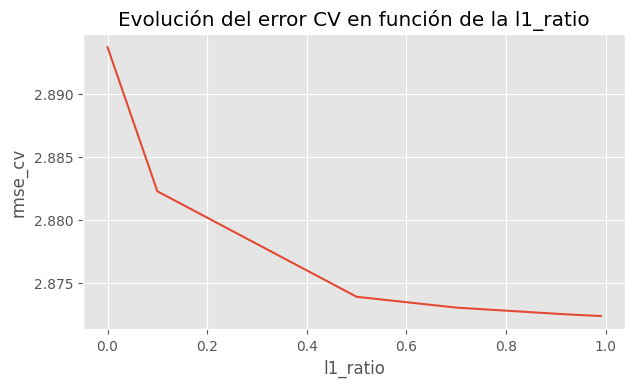

In [34]:
# Mejor valor encontrado para cada l1_ratio
fig, ax = plt.subplots(figsize=(7, 3.84))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv')

In [35]:
# Mejor valor alpha y l1_ratio_ encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo.l1_ratio_}")

Mejor valor de alpha encontrado: 0.10353218432956658
Mejor valor de l1_ratio encontrado: 0.99


In [36]:
# Coeficientes del modelo
# ===================================
df_coeficientes = pd.DataFrame({
    'predictor': feature_names,
    'coef'     : modelo.coef_.flatten()
})
df_coeficientes

,predictor,coef
0,age,-0.00000
1,daily_social_media_hours,0.00000
2,sleep_hours,-0.00000
3,screen_time_before_sleep,0.00000
4,academic_performance,0.00000
5,physical_activity,0.00000
6,anxiety_level,0.00000
7,addiction_level,-0.00000
8,depression_label,0.39678
9,gender_male,0.00000


Text(0.5, 1.0, 'Coeficientes del modelo Elastic Net')

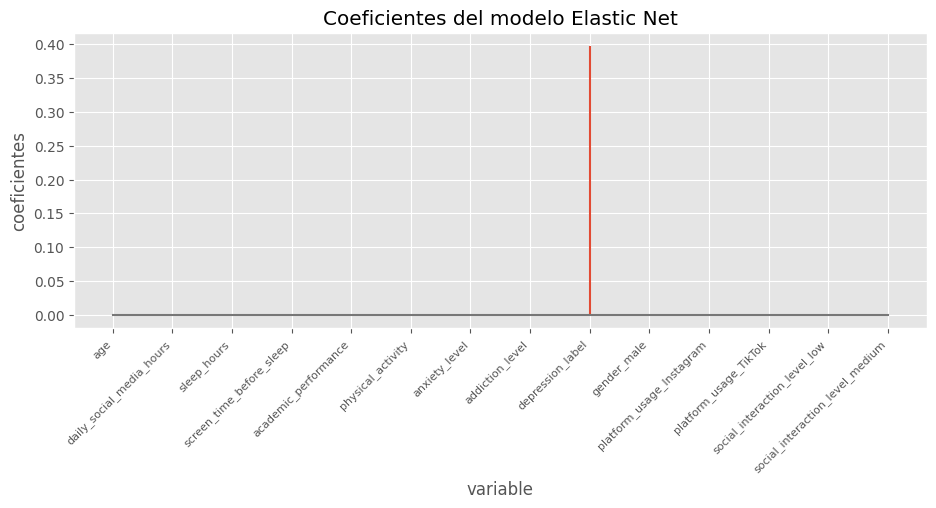

In [37]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=45, ha='right', size=8)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo Elastic Net')

In [38]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=df_test)
predicciones = predicciones.flatten()

In [39]:
# Error de test del modelo
# ==============================================================================
rmse_elastic = np.sqrt(mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
))
print("")
print(f"El error (rmse) de test es: {rmse_elastic}")


El error (rmse) de test es: 2.845815924963854


# <font color="#0000ff">COMPARACIÓN DE MODELOS</font>

In [40]:
df_comparacion = pd.DataFrame({
    'modelo'   : ['OLS', 'Ridge', 'Lasso', 'Elastic-net'],
    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
})
df_comparacion

,modelo,test rmse
0,OLS,2.844053
1,Ridge,2.845413
2,Lasso,2.879648
3,Elastic-net,2.845816



🏆 Mejor modelo: OLS (RMSE = 2.8441)


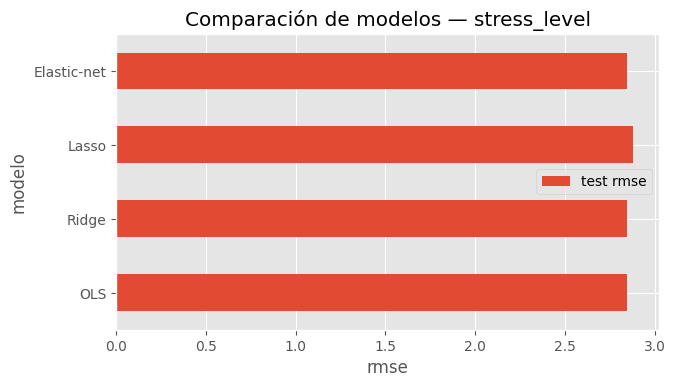

In [41]:
fig, ax = plt.subplots(figsize=(7, 3.84))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos — stress_level')

# Indicar el mejor modelo
mejor_modelo = df_comparacion.loc[df_comparacion['test rmse'].idxmin(), 'modelo']
mejor_rmse   = df_comparacion['test rmse'].min()
print(f"\n🏆 Mejor modelo: {mejor_modelo} (RMSE = {mejor_rmse:.4f})")